# Setup

In [1]:
# Standard library imports
import warnings
import os
import math
import copy
from dataclasses import dataclass
from random import shuffle

# Third-party imports: core data handling
import numpy as np
import pandas as pd

# Third-party imports: modeling
import scipy.optimize as opt
from scipy.stats import norm, pearsonr
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.cluster import KMeans
from gensim.models import Word2Vec

# Third-party imports: visualization
import matplotlib.pyplot as plt

# Configuration & Settings
warnings.simplefilter(action='ignore', category=FutureWarning)

Let's break down the imports step-by-step:

The **standard library** block brings in `warnings` (so we can silence `FutureWarning` messages from pandas and scikit-learn), `os` for file paths, `math` for scalar special functions - we will need `math.lgamma`, the log-gamma function, when fitting the Beta–Binomial layer of TSB-HB - `copy` and `shuffle` for the cat2vec helper in the final section, and `dataclass`, a decorator that lets us define a small typed container for the fitted TSB-HB parameters without writing boilerplate.

The **core data** block imports `numpy` under the conventional alias `np` (fast array math) and `pandas` as `pd` (labeled DataFrames, which we use for everything tabular).

The **modeling** block is where the domain-specific machinery lives. `scipy.optimize` (aliased `opt`) provides the L-BFGS-B numerical optimizer we use to maximize the Beta–Binomial marginal likelihood and the REML criterion in TSB-HB. From `scipy.stats` we take `norm` (the normal distribution, used for Monte Carlo sampling of log-demand sizes) and `pearsonr` (to quantify shrinkage later). `lightgbm` is the gradient boosting library used in the at-scale section. From scikit-learn we take `LabelEncoder` (integer-encode categorical columns for LightGBM), `Ridge` and `MultiOutputRegressor` (a simple multi-output baseline for new launches), and `KMeans` (clustering products by embedding). `Word2Vec` from `gensim` powers the cat2vec trick for embedding categorical product attributes.

Finally, `matplotlib.pyplot` is imported as `plt` for all plotting, and the configuration line tells the `warnings` module to ignore `FutureWarning`s - they are about *upcoming* API changes and would otherwise clutter our output.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    metric = 'rmse'
    horizon = 28          # length of the holdout window, in days

# display style
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

We gather every knob the notebook depends on into a single `CFG` class, so that changing a path or a figure size requires editing exactly one place:

- `data_folder` points at the [M5 Forecasting competition data](https://www.kaggle.com/c/m5-forecasting-accuracy) — daily Walmart sales, the workhorse dataset of this notebook. `launch_folder` points at the (preprocessed) VISUELLE fashion dataset used in the new-launches section.
- `img_dim1` / `img_dim2` set a wide 20×10 default figure size — intermittent series are long and spiky, so they need horizontal room.
- `SEED = 42` is fed to `np.random.seed`, which fixes NumPy's random number generator. This matters because TSB-HB's probabilistic forecasts are produced by Monte Carlo sampling, and KMeans uses random initialization — with a fixed seed the notebook produces *identical* numbers on every run, which is essential for reproducibility.
- `metric = 'rmse'` records our headline point-forecast metric, and `horizon = 28` is the length of the chronological holdout — 28 days, matching the M5 competition's forecast horizon.

The two `plt` lines select the `fivethirtyeight` style sheet and apply the default figure size globally, so individual plotting cells stay clean.

# Utils

In [3]:
def forecast_metrics(y_true, y_pred):
    '''Point-forecast metrics: mean error (bias), MAE and RMSE.'''
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'me':   float(np.round(np.nanmean(y_pred - y_true), 4)),
        'mae':  float(np.round(np.nanmean(np.abs(y_pred - y_true)), 4)),
        'rmse': float(np.round(np.sqrt(np.nanmean((y_pred - y_true) ** 2)), 4)),
    }

`forecast_metrics` takes the observed values `y_true` and the forecasts `y_pred`, coerces both into float NumPy arrays with `np.asarray` (so the function accepts pandas Series and plain lists alike), and returns a dictionary of three rounded scalars:

- **ME** (mean error): the average of `y_pred - y_true`. Unlike the other two, errors of opposite sign cancel, so ME measures *systematic bias* => a negative ME means the model under-forecasts on average. Bias matters operationally: a biased demand forecast translates directly into systematic over- or under-stocking.
- **MAE** (mean absolute error): the average magnitude of the error, in the original units (units sold per day).
- **RMSE** (root mean squared error): squares the errors before averaging, so large misses are penalized disproportionately. This is our primary metric (per `CFG.metric`), since in inventory management a few huge errors hurt more than many tiny ones.

We use `np.nanmean` rather than `np.mean` throughout so that any NaN padding in a forecast array is ignored rather than poisoning the result, and we convert to native `float` and round to 4 decimals so the dictionaries print cleanly.

In [4]:
def rmsse_per_series(train_panel, eval_panel, pred_col='y_pred'):
    '''Root Mean Squared Scaled Error per series.

    The denominator is the in-sample MSE of the naive (lag-1) forecast,
    computed on the training window; the numerator is the model's MSE
    on the evaluation window. Returns a Series indexed by unique_id.
    '''
    tr = train_panel.sort_values(['unique_id', 'ds']).copy()
    tr['y_lag1'] = tr.groupby('unique_id')['y'].shift(1)
    naive_mse = ((tr['y'] - tr['y_lag1']) ** 2).groupby(tr['unique_id']).mean()
    naive_mse = naive_mse.where(naive_mse > 0, 1e-9)

    ev = eval_panel.copy()
    model_mse = ((ev['y'] - ev[pred_col]) ** 2).groupby(ev['unique_id']).mean()

    return np.sqrt(model_mse / naive_mse).rename('rmsse')

RMSE has a problem when we evaluate across *many* series at once: a product that sells 50 units a day contributes errors on a completely different scale than one selling 0.2 units a day, so a simple average of RMSEs is dominated by the high-volume items. The **RMSSE** (Root Mean Squared *Scaled* Error) - the headline metric of the M5 competition and of the TSB-HB paper - fixes this by dividing each series' squared error by the in-sample squared error of the **naive lag-1 forecast** ("tomorrow equals today") on that same series.

The function works in two halves. First, on the training panel, it sorts by series and date, creates the one-step-lagged demand with `groupby('unique_id')['y'].shift(1)` (the `groupby` ensures the shift never leaks across series boundaries), and computes the mean squared difference per series — that is the scaling denominator. The `.where(naive_mse > 0, 1e-9)` guard replaces a zero denominator (which happens for an all-constant training series) with a tiny epsilon, avoiding division by zero. Second, it computes the model's mean squared error per series on the evaluation panel and returns the square root of the ratio.

Interpretation: **RMSSE < 1 means the model beats the naive forecast** on that series; RMSSE > 1 means it loses to it. Because the scale cancels, RMSSE values are comparable and averageable across items of wildly different volume.

In [5]:
def train_valid_split(panel, horizon=CFG.horizon, date_col='ds'):
    '''Chronological split: the last `horizon` days form the validation set.'''
    cutoff = panel[date_col].max() - pd.to_timedelta(horizon, unit='D')
    train = panel.loc[panel[date_col] <= cutoff].copy()
    valid = panel.loc[panel[date_col] > cutoff].copy()
    return train, valid

`train_valid_split` computes a `cutoff` date by subtracting `horizon` days (28 by default, from `CFG`) from the latest date in the panel via `pd.to_timedelta`, then returns everything up to the cutoff as training data and everything after as validation. Both slices are `.copy()`-ed so that later in-place modifications (adding columns, dropping rows) cannot trigger pandas' `SettingWithCopyWarning` or silently mutate the original frame. Paranoid people live longer.

In [6]:
def classify_intermittency(panel):
    '''Classify each series into Smooth / Erratic / Intermittent / Lumpy
    using the ADI / CV^2 framework of Syntetos, Boylan & Croston (2005).'''
    out = []
    for uid, g in panel.groupby('unique_id'):
        y = g['y'].values
        nonzero = y[y > 0]
        if len(nonzero) == 0:
            continue
        adi = len(y) / len(nonzero)                       # average demand interval
        cv2 = (nonzero.std() / nonzero.mean()) ** 2 if len(nonzero) > 1 else 0.0
        if adi < 1.32:
            cat = 'smooth' if cv2 < 0.49 else 'erratic'
        else:
            cat = 'intermittent' if cv2 < 0.49 else 'lumpy'
        out.append({'unique_id': uid, 'adi': round(adi, 2),
                    'cv2': round(cv2, 2), 'category': cat})
    return pd.DataFrame(out)

Not all "spiky" series are alike, and the standard way to talk about them is the two-dimensional classification of Syntetos, Boylan & Croston (2005), built from two statistics computed per series:

- **ADI** (Average Demand Interval): the number of periods divided by the number of periods *with* demand. ADI = 1 means demand occurs every day; ADI = 5 means, on average, one sale every five days. It measures intermittency **in time**.
- **CV²** (squared coefficient of variation of the *positive* demand sizes): the variance of the nonzero demands relative to their squared mean. It measures volatility **in size**, ignoring the zeros.

The function loops over series with `groupby('unique_id')`, extracts the nonzero demands, computes both statistics, and applies the standard thresholds ADI = 1.32 and CV² = 0.49 to assign one of four labels:

| | CV² < 0.49 | CV² ≥ 0.49 |
|---|---|---|
| **ADI < 1.32** | smooth | erratic |
| **ADI ≥ 1.32** | intermittent | lumpy |

"Smooth" series are what classical methods (ARIMA, exponential smoothing) are built for. The Croston family targets the bottom row: **intermittent** (regular sizes, irregular timing) and **lumpy** (irregular in both), which is where most of a retail catalog lives. The `if len(nonzero) > 1 else 0.0` guard handles series with a single sale, for which a standard deviation is undefined.

In [7]:
def plot_forecast(dates, actual, forecasts, title=''):
    '''Overlay the observed series with one or more forecasts.

    `forecasts` is a dict: label -> array of predictions aligned with `dates`.
    '''
    plt.figure()
    plt.plot(dates, actual, linewidth=2, label='observed')
    palette = ['red', 'green', 'darkorange']
    for (label, pred), col in zip(forecasts.items(), palette):
        plt.plot(dates, pred, color=col, linestyle='--', linewidth=2, label=label)
    plt.title(title)
    plt.legend()
    plt.show()

The observed series is drawn first with the default color and `linewidth=2`; each forecast from the `forecasts` dictionary is drawn as a dashed line in a fixed palette (first forecast red, second green, third orange), so the *same method always gets the same color* across every figure and the plots can be compared at a glance. `plt.legend()` is always called and the title names the method(s) being shown.

# Groundwork

We use the data from the **M5 competition** ([kaggle.com/c/m5-forecasting-accuracy](https://www.kaggle.com/c/m5-forecasting-accuracy)): hierarchical daily unit-sales data from Walmart covering 3049 products across 10 stores in 3 US states, with the task of forecasting daily sales 28 days ahead. To keep memory in check we restrict ourselves to California.

In [8]:
xdat = pd.read_csv(CFG.data_folder + 'sales_train_validation.csv.zip', compression='zip')
xdat = xdat.loc[xdat.state_id == 'CA']
xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1


`pd.read_csv` loads the sales file into a DataFrame. The raw M5 data comes in **wide format**: one row per product × store combination, with id columns (`item_id`, `dept_id`, `cat_id`, `store_id`, `state_id`) followed by 1913 columns named `d_1` … `d_1913`, one per calendar day. The `.loc[xdat.state_id == 'CA']` filter keeps only the Californian stores.

The `head(3)` at the end of the cell is a bare expression, so Jupyter displays it: a quick sanity check that the load and the filter did what we expect.

In [9]:
# melt the data into long format
xdat = pd.melt(xdat,
               id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
               var_name='d', value_name='sales').dropna()

# get proper timestamps
xcal = pd.read_csv(CFG.data_folder + 'calendar.csv')
xdat = pd.merge(xdat, xcal, on='d', how='left')
del xcal

# drop what we will not need
xdat.drop(['d', 'wm_yr_wk', 'weekday', 'month', 'year', 'event_name_1', 'event_type_1',
           'event_name_2', 'event_type_2', 'snap_TX', 'snap_WI', 'state_id'],
          axis=1, inplace=True)
xdat['date'] = pd.to_datetime(xdat['date'])
xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,sales,date,wday,snap_CA
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0


Three transformations happen here. First, `pd.melt` reshapes the table from wide to **long format**: the day columns `d_1`…`d_1913` are stacked into a single `d` column with the daily sales in a `sales` column, while the columns listed in `id_vars` are repeated as identifiers. Long format = one row per (item, store, day)  is what every method in this notebook expects.

Next, the day labels `d_i` are not real dates, so we load the M5 `calendar.csv`, which maps each `d_*` label to an actual calendar date plus event metadata, and `pd.merge` it onto the sales frame with a left join on `d` (left join: keep every sales row, attach calendar info where it matches). The `del xcal` frees the calendar frame.

Finally, `drop(..., inplace=True)` removes columns we will not use (the raw day label, week ids, event columns, SNAP indicators for the other states; `inplace=True` modifies the frame directly instead of returning a copy), and `pd.to_datetime` converts the `date` column from strings into proper datetime objects. This is what later makes chronological comparisons like `df.date >= '2012-01-01'` and timedelta arithmetic work. 

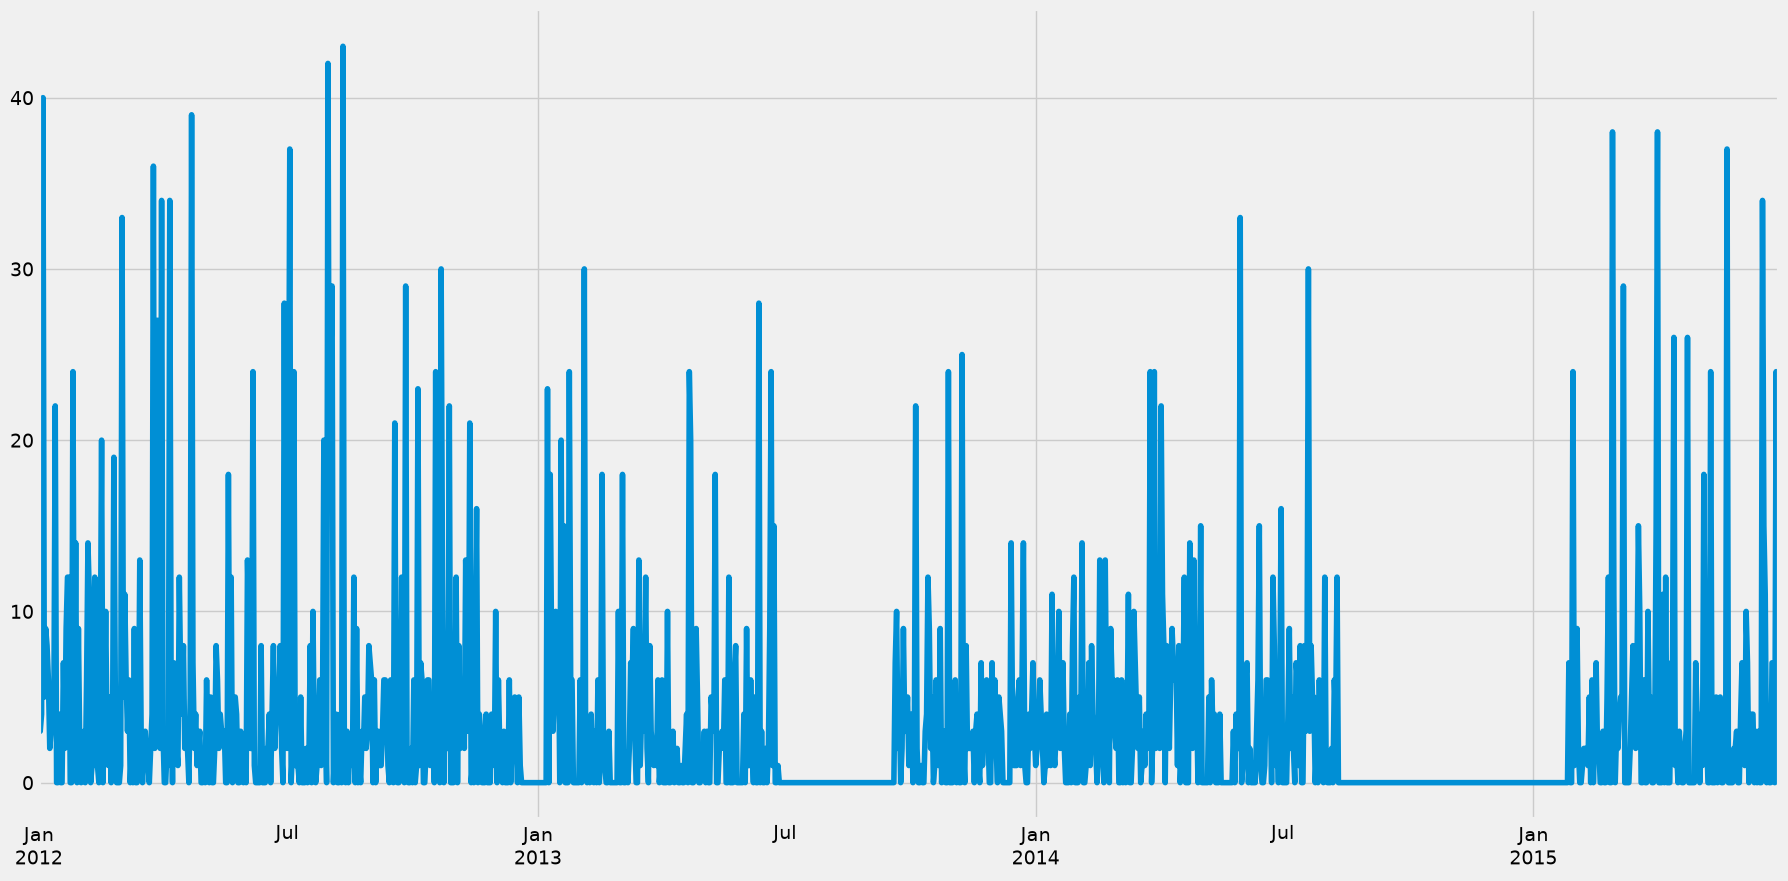

In [10]:
df = xdat.loc[(xdat.item_id == 'HOBBIES_1_288') & (xdat.store_id == 'CA_1')][['date', 'sales']].copy()
df = df.loc[(df.date >= '2012-01-01') & (df.date <= '2015-06-30')]
df.set_index('date').sales.plot(xlabel='')
print()

Before any modeling, we always look at the raw data. We subset a single product x store combination: item `HOBBIES_1_288` in store `CA_1` , restrict it to a 3.5 year window, set the date as the index, and call the pandas `.plot()` accessor on the sales Series (the trailing `print()` suppresses the matplotlib object repr).

In [11]:
panel_one = df.rename(columns={'date': 'ds', 'sales': 'y'}).assign(unique_id='HOBBIES_1_288_CA_1')
classify_intermittency(panel_one)

,unique_id,adi,cv2,category
0,HOBBIES_1_288_CA_1,1.91,1.25,lumpy


We run our classifier on this single series (renaming columns to the `unique_id` / `ds` / `y` convention the helper expects — the same convention used by the `statsforecast` ecosystem and the TSB-HB reference code). The result: an ADI above 1.32 => demand occurs only every few days, so the series is in the bottom row of the classification matrix. 

Depending on the size variability it lands in the **intermittent** or **lumpy** cell; either way, this is exactly the demand pattern the Croston family was designed for, and in the TSB-HB paper's Online Retail panel these two categories together cover over 97% of all SKUs. 

# Croston family

## Basic Croston

In [12]:
# Based on: https://medium.com/towards-data-science/croston-forecast-model-for-intermittent-demand-360287a17f5f


def Croston(ts, extra_periods=1, alpha=0.4):

    d = np.array(ts)                          # Transform the input into a numpy array
    cols = len(d)                             # Historical period length
    d = np.append(d, [np.nan] * extra_periods)  # Append np.nan to cover future periods

    # level (a), periodicity (p) and forecast (f)
    a, p, f = np.full((3, cols + extra_periods), np.nan)
    q = 1  # periods since last demand observation

    # Initialization
    first_occurence = np.argmax(d[:cols] > 0)
    a[0] = d[first_occurence]
    p[0] = 1 + first_occurence
    f[0] = a[0] / p[0]

    # Create all the t+1 forecasts
    for t in range(0, cols):
        if d[t] > 0:
            a[t + 1] = alpha * d[t] + (1 - alpha) * a[t]
            p[t + 1] = alpha * q + (1 - alpha) * p[t]
            f[t + 1] = a[t + 1] / p[t + 1]
            q = 1
        else:
            a[t + 1] = a[t]
            p[t + 1] = p[t]
            f[t + 1] = f[t]
            q += 1

    # Future Forecast
    a[cols + 1:cols + extra_periods] = a[cols]
    p[cols + 1:cols + extra_periods] = p[cols]
    f[cols + 1:cols + extra_periods] = f[cols]

    return pd.DataFrame.from_dict({'Demand': d, 'Forecast': f, 'Period': p,
                                   'Level': a, 'Error': d - f})

First, the input series is converted to a NumPy array and padded with `extra_periods` NaN values: the loop produces a one-step-ahead value at every index, so the padding makes room for the out-of-sample forecast. Three state arrays: level `a`, periodicity `p`, forecast `f`, are allocated in one shot with `np.full((3, ...), np.nan)`, and `q`, the counter of periods since the last sale, starts at 1.

Next comes initialization: `np.argmax(d[:cols] > 0)` returns the index of the **first positive demand**, which seeds the level (`a[0]` = that demand) and the period (`p[0]` = 1 + how long we waited for it). Without a sensible start the smoother would take a long time to recover from an arbitrary one.

The main loop : on a demand day, both smoothers update and `q` resets to 1; on a zero day, **nothing changes** except `q` ticking up. After the loop, the last state is simply propagated flat across the future periods: Croston's out-of-sample forecast is a constant.

The function returns a DataFrame holding the demand, the forecast, both internal states and the per-period error, which makes inspection and plotting one-liners.

In [13]:
HORIZON = CFG.horizon       # 28-day holdout
ALPHA = 0.4                 # smoothing constant for level and interval

train_y, valid_y = df.iloc[:-HORIZON], df.iloc[-HORIZON:]

fit_croston = Croston(train_y.sales, extra_periods=HORIZON, alpha=ALPHA)
pred_croston = fit_croston.Forecast.tail(HORIZON).values

forecast_metrics(valid_y.sales, pred_croston)

{'me': -3.1074, 'mae': 4.8393, 'rmse': 8.3298}

The constants are declared: 28-day holdout matching `CFG.horizon`, and $\alpha = 0.4$ (higher $\alpha$ = faster reaction, more noise).

The split is chronological: `df.iloc[:-HORIZON]` keeps everything except the last 28 rows for training, `df.iloc[-HORIZON:]` holds out the final 28 days. This simulates a  real situation of forecasting unseen future days. We fit Croston on the training window only, asking for `extra_periods=HORIZON` future values, and slice them out with `.tail(HORIZON)` — by construction these are the constant out-of-sample forecast.

The metrics dictionary gives our first baseline numbers. Note what the RMSE of a *constant* forecast against a spiky series means: the model cannot, and does not try to, predict *which* day the spikes land on; it aims at the correct **average demand per period**, which is exactly the quantity inventory planning needs.

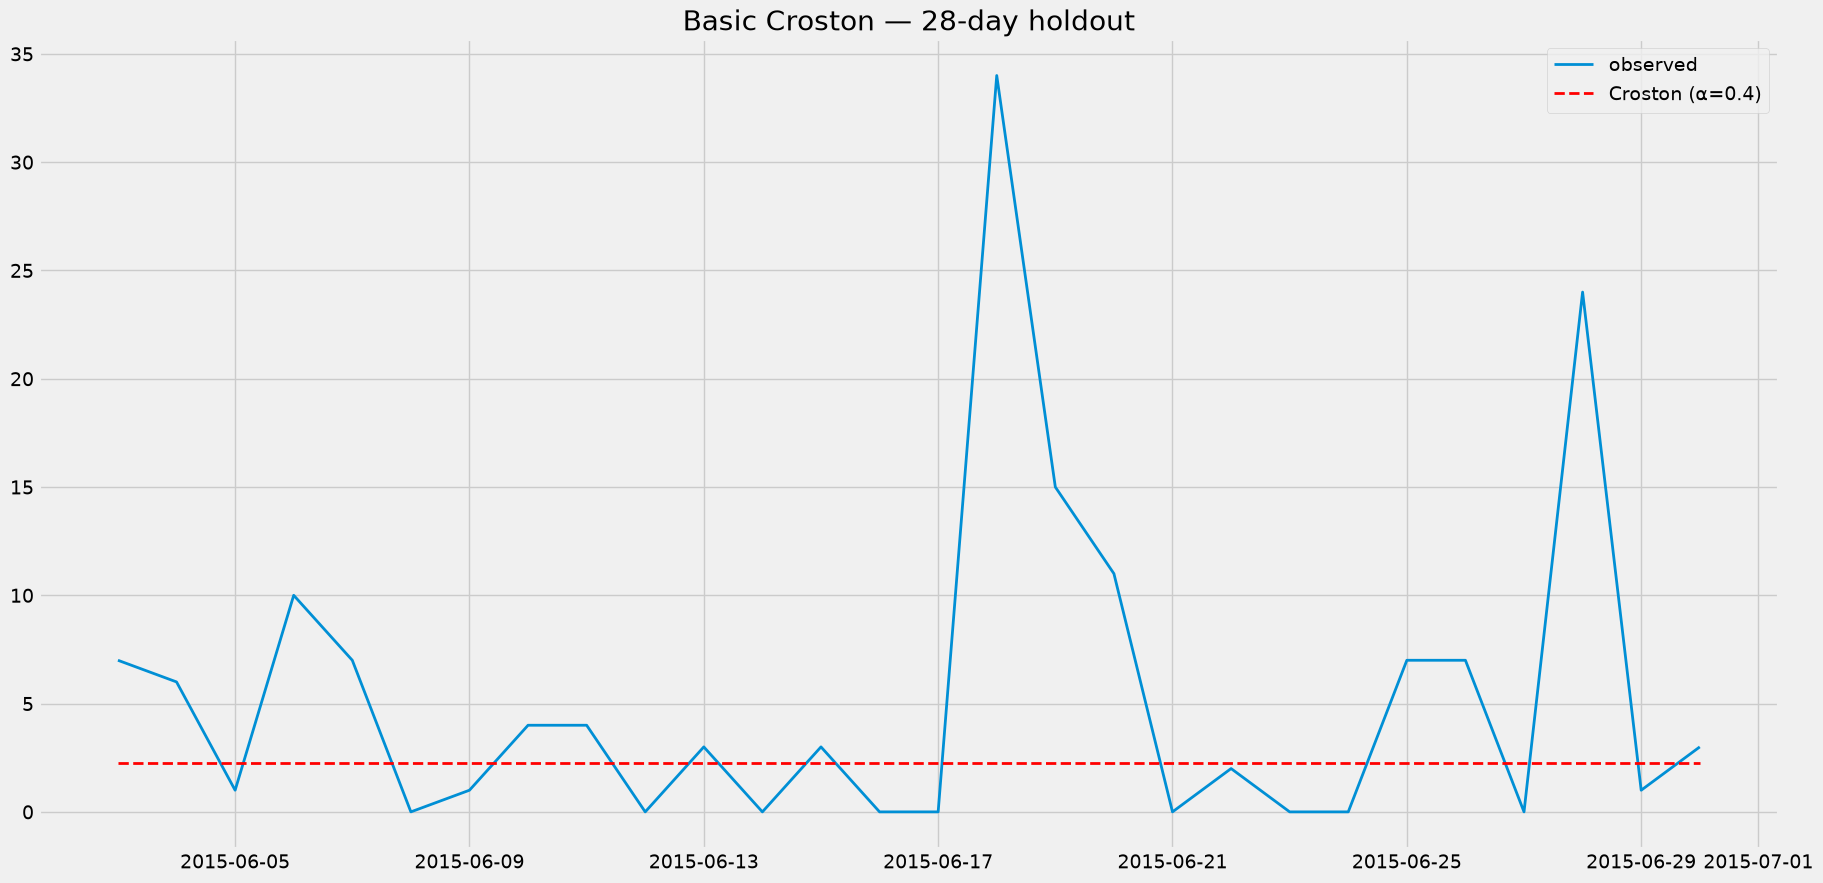

In [14]:
plot_forecast(valid_y.date, valid_y.sales,
              {f'Croston (α={ALPHA})': pred_croston},
              title='Basic Croston — 28-day holdout')

## Croston-TSB

In [15]:
def Croston_TSB(ts, extra_periods=1, alpha=0.4, beta=0.1):
    d = np.array(ts)                          # Transform the input into a numpy array
    cols = len(d)                             # Historical period length
    d = np.append(d, [np.nan] * extra_periods)  # Append np.nan to cover future periods

    # level (a), probability (p) and forecast (f)
    a, p, f = np.full((3, cols + extra_periods), np.nan)

    # Initialization
    first_occurence = np.argmax(d[:cols] > 0)
    a[0] = d[first_occurence]
    p[0] = 1 / (1 + first_occurence)
    f[0] = p[0] * a[0]

    # Create all the t+1 forecasts
    for t in range(0, cols):
        if d[t] > 0:
            a[t + 1] = alpha * d[t] + (1 - alpha) * a[t]
            p[t + 1] = beta * 1 + (1 - beta) * p[t]
        else:
            a[t + 1] = a[t]
            p[t + 1] = (1 - beta) * p[t]
        f[t + 1] = p[t + 1] * a[t + 1]

    # Future Forecast
    a[cols + 1:cols + extra_periods] = a[cols]
    p[cols + 1:cols + extra_periods] = p[cols]
    f[cols + 1:cols + extra_periods] = f[cols]

    return pd.DataFrame.from_dict({'Demand': d, 'Forecast': f, 'Probability': p,
                                   'Level': a, 'Error': d - f})

The structure mirrors `Croston`: same padding, same state arrays, same flat future => the two functions can be diffed line by line, and the differences *are* the model change. There are three:
1. The initialization of `p[0]` is now `1/(1 + first_occurence)`: it is a probability (waiting 4 days for the first sale ≈ a 20% daily chance), not an interval. 
2. The `else` branch: `p[t+1] = (1-beta)*p[t]` decays the occurrence probability **on every zero-demand day** - this is the obsolescence fix. 
3. the forecast `f[t+1] = p[t+1] * a[t+1]` is computed *every* period, outside the if/else, as the product of probability and level.

There are now two smoothing constants: $\alpha$ for the size, $\beta$ for the probability. The TSB-HB paper notes the method's sensitivity to this pair — their benchmark grid-searches it — which foreshadows the appeal of a model that has *no* per-series smoothing constants at all.

In [16]:
ALPHA_TSB, BETA_TSB = 0.1, 0.1

fit_tsb = Croston_TSB(train_y.sales, extra_periods=HORIZON, alpha=ALPHA_TSB, beta=BETA_TSB)
pred_tsb = fit_tsb.Forecast.tail(HORIZON).values

forecast_metrics(valid_y.sales, pred_tsb)

{'me': -1.7235, 'mae': 4.8762, 'rmse': 7.9183}

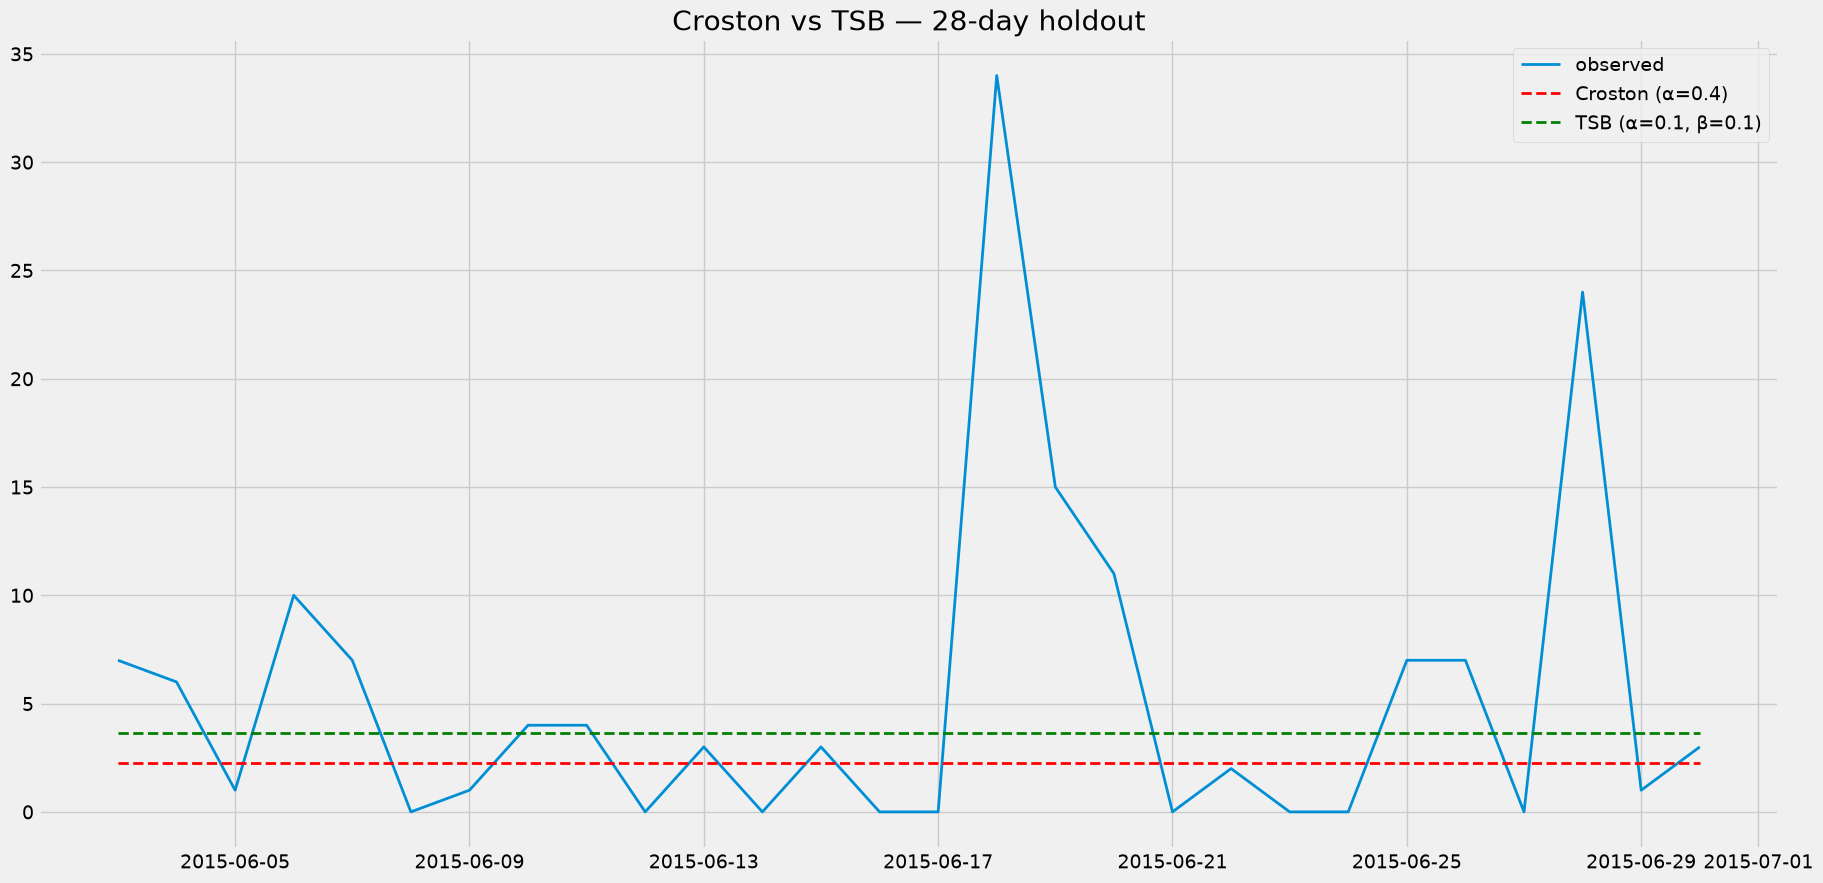

In [17]:
plot_forecast(valid_y.date, valid_y.sales,
              {f'Croston (α={ALPHA})': pred_croston,
               f'TSB (α={ALPHA_TSB}, β={BETA_TSB})': pred_tsb},
              title='Croston vs TSB — 28-day holdout')

## TSB-HB: a hierarchical Bayesian TSB

In [18]:
@dataclass
class TSBHBParams:
    # all Series are indexed by unique_id
    p_posterior: pd.Series        # posterior mean occurrence probability per item
    shrunk_mean_log: pd.Series    # posterior mean of mu_i (log-size) per item
    posterior_var_mu: pd.Series   # posterior variance of mu_i per item
    sigma_sq_process: float       # pooled within-item log-size variance


def beta_binom_log_marginal(s, n, alpha, beta):
    '''Log marginal likelihood of s successes in n trials under Beta(alpha, beta).'''
    if alpha <= 0 or beta <= 0 or s < 0 or n < s:
        return -np.inf
    return (math.lgamma(n + 1) - math.lgamma(s + 1) - math.lgamma(n - s + 1)
            + math.lgamma(s + alpha) + math.lgamma(n - s + beta)
            - math.lgamma(n + alpha + beta)
            - (math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)))


def estimate_beta_hyperparams(s_arr, n_arr):
    '''Maximize the Beta-Binomial marginal likelihood over the panel.'''
    valid = (n_arr > 0) & (s_arr <= n_arr)
    s_arr, n_arr = s_arr[valid], n_arr[valid]

    def objective(params):
        alpha, beta = params
        if alpha <= 0 or beta <= 0:
            return np.inf
        ll = [beta_binom_log_marginal(int(si), int(ni), float(alpha), float(beta))
              for si, ni in zip(s_arr, n_arr)]
        return -float(np.sum(ll))

    result = opt.minimize(objective, x0=[1.0, 10.0], method='L-BFGS-B',
                          bounds=[(1e-6, None), (1e-6, None)])
    if not result.success:
        return 1.0, 1.0
    return float(result.x[0]), float(result.x[1])

Two building blocks for the occurrence layer: the `TSBHBParams` dataclass is a typed container for everything `fit` produces and `predict` consumes (= three per-item Series and one scalar).

`beta_binom_log_marginal` computes, for one item, the log probability of observing `s` demand days out of `n` days when the item's unknown probability has been *integrated out* against a $\text{Beta}(\alpha,\beta)$ prior. The closed form is a ratio of Beta functions, writtenin terms of the log of the gamma function: working in log space avoids the catastrophic overflow that raw factorials of $n \approx 1800$ days would cause. The guard clause returns `-np.inf` for invalid parameter or data combinations, which the optimizer interprets as "infinitely bad" and steps away from.

`estimate_beta_hyperparams` is the **empirical Bayes** step: we pick the $(\alpha, \beta)$ under which the *observed panel* (= all the $(m_i, n_i)$ pairs at once) is most probable. The inner `objective` sums the per-item log marginals and negates the total (optimizers minimize), and `opt.minimize` with the quasi-Newton method `L-BFGS-B` searches the two-dimensional space, with `bounds` keeping both parameters strictly positive. The starting point $(1, 10)$ encodes a mild guess that demand days are the minority. This single small optimization is the only iterative fitting the occurrence model ever needs. After it, every item's posterior is a closed-form one-liner.

In [19]:
def fit_tsb_hb(train_df):
    '''Fit TSB-HB on a long panel with columns unique_id, ds, y.

    - occurrence: Beta-Binomial empirical Bayes, shared (alpha, beta)
    - size: Log-Normal with REML-estimated random intercept (credibility shrinkage)
    '''
    init_set = train_df.copy()
    init_set['occ'] = (init_set['y'] > 0).astype(int)
    init_set['size'] = np.where(init_set['occ'] == 1, init_set['y'].astype(float), np.nan)
    init_set['log_size'] = np.log(init_set['size'])     # NaN on zero-demand days

    # --- occurrence layer ---
    g_init = init_set.groupby('unique_id')
    s = g_init['occ'].sum()           # demand days per item (m_i)
    n = g_init['ds'].nunique()        # observed days per item (n_i)

    alpha_hat, beta_hat = estimate_beta_hyperparams(s.values.astype(int), n.values.astype(int))
    p_post_mean = (alpha_hat + s) / (alpha_hat + beta_hat + n)

    # --- size layer ---
    item_stats = g_init['log_size'].agg(n_pos='count', mean_log='mean', var_log='var').reset_index()
    item_stats = item_stats.fillna({'var_log': 0})
    multi = item_stats[item_stats['n_pos'] > 1].copy()

    # pooled within-item variance sigma^2 (weighted by degrees of freedom)
    sigma_sq = (np.sum((multi['n_pos'] - 1) * multi['var_log'])
                / max(np.sum(multi['n_pos'] - 1), 1e-9))

    y_i, n_i = multi['mean_log'].values, multi['n_pos'].values

    # method-of-moments starting value for the between-item variance tau^2
    observed_var = np.var(y_i, ddof=1) if len(y_i) > 1 else 0.0
    tau_sq_mom = max(observed_var - float(np.mean(sigma_sq / n_i)), 1e-6)

    def reml_neg_log_likelihood(tau_sq):
        if tau_sq <= 0:
            return np.inf
        V_i = tau_sq + sigma_sq / n_i
        weights = 1.0 / V_i
        mu_hat = np.sum(weights * y_i) / np.sum(weights)
        return float(np.sum(np.log(V_i)) + np.sum((y_i - mu_hat) ** 2 / V_i)
                     + np.log(np.sum(weights)))

    res = opt.minimize(lambda x: reml_neg_log_likelihood(x[0]), x0=[tau_sq_mom],
                       method='L-BFGS-B', bounds=[(1e-9, None)])
    tau_sq = max(float(res.x[0]) if res.success else tau_sq_mom, 1e-6)

    # GLS estimate of the global mean mu_0
    weights = 1.0 / (tau_sq + sigma_sq / n_i)
    global_mean = float(np.sum(weights * y_i) / np.sum(weights))

    # credibility weights w_i = n_pos / (n_pos + sigma^2/tau^2) and shrunk means
    item_stats['credibility'] = item_stats['n_pos'] / (item_stats['n_pos'] + sigma_sq / tau_sq)
    item_stats['shrunk_mean_log'] = (item_stats['credibility'] * item_stats['mean_log'].fillna(global_mean)
                                     + (1 - item_stats['credibility']) * global_mean)
    item_stats['posterior_var_mu'] = (sigma_sq * tau_sq) / (item_stats['n_pos'] * tau_sq + sigma_sq)
    item_stats.loc[item_stats['n_pos'] == 0, 'posterior_var_mu'] = tau_sq

    params = item_stats.set_index('unique_id')[['shrunk_mean_log', 'posterior_var_mu']]
    params['p_posterior'] = p_post_mean

    return TSBHBParams(p_posterior=params['p_posterior'],
                       shrunk_mean_log=params['shrunk_mean_log'],
                       posterior_var_mu=params['posterior_var_mu'],
                       sigma_sq_process=float(sigma_sq))

The preparation step decomposes the panel: an `occ` indicator (1 on demand days), the positive `size` (NaN on zero days, via `np.where`), and its log. Putting NaN on zero-demand days is essential: the size model is *conditional on demand occurring*, and pandas aggregations like `count`, `mean`, `var` silently skip NaNs, which is exactly the conditioning needed

The **occurrence layer** then needs only two sufficient statistics per item:
1.  `s` (demand days, our $m_i$, via a grouped sum of the indicator) 
2.  `n` (observed days, $n_i$) = feeds them to the hyperparameter optimizer from the previous cell, and computes every item's posterior mean $\hat\pi_i = (\hat\alpha + m_i)/(\hat\alpha + \hat\beta + n_i)$ in a single vectorized line.

The **size layer** estimates the variance components of the random-intercept model. First $\sigma^2$, the *within*-item noise, as the degrees-of-freedom-weighted average of the per-item log-size variances (only items with `n_pos > 1` can contribute). Then $\tau^2$, the *between*-item spread, by minimizing the **REML** (restricted maximum likelihood) criterion: the three terms in `reml_neg_log_likelihood` are the Gaussian log-determinant and weighted residual sum of squares, plus the `log(sum(weights))` correction that makes REML account for having estimated the global mean 

A method-of-moments value (observed spread of item means minus their average sampling noise) provides a starting point. Given $\hat\tau^2$, the global mean $\hat\mu_0$ is the generalized-least-squares weighted average, where precise items (many sales, small $\sigma^2/n_i$) weigh more.

The closed-form posteriors: the credibility weight $w_i = n_{pos}/(n_{pos} + \sigma^2/\tau^2)$ blends each item's mean log-size with the global mean, and the posterior variance of $\mu_i$ shrinks toward 0 as evidence accumulates. 

The edge cases fall out of the same formula: an item with a single sale gets the small $n_{pos}=1$ weight, an item with no sales gets weight 0 = **the cold-start item is forecast entirely from the panel prior**, with the full prior uncertainty $\tau^2$ attached.

In [20]:
def predict_tsb_hb(params, eval_df, quantiles=None, n_samples=2000):
    '''Forecast on an evaluation panel (columns unique_id, ds).

    - point forecast: constant per-series mean, replicated across the horizon
    - probabilistic: Monte Carlo draws from the generative model -> quantiles
    '''
    if quantiles is None or len(quantiles) == 0:
        # E[Y] = p * E[size]; lognormal mean = exp(mu + (sigma^2 + var_mu)/2)
        size_mean = np.exp(params.shrunk_mean_log
                           + (params.sigma_sq_process + params.posterior_var_mu) / 2.0)
        mean_pred = (params.p_posterior * size_mean).fillna(0.0)
        out = eval_df[['unique_id', 'ds']].copy()
        out['y_pred'] = out['unique_id'].map(mean_pred).fillna(0.0)
        return out

    rows = []
    for uid in eval_df['unique_id'].unique():
        if uid not in params.p_posterior.index:
            continue
        p = float(params.p_posterior.get(uid, 0.0))
        mu = float(params.shrunk_mean_log.get(uid, 0.0))
        pred_std = float(np.sqrt(params.sigma_sq_process + params.posterior_var_mu.get(uid, 0.0)))

        # zero-inflation x lognormal draws
        demand_occurs = np.random.binomial(1, p, n_samples)
        size_samples = np.exp(norm.rvs(loc=mu, scale=pred_std, size=n_samples))
        samples = size_samples * demand_occurs

        qvals = {f'q_{q}': float(np.quantile(samples, q)) for q in quantiles}
        ds_vals = eval_df.loc[eval_df['unique_id'] == uid, 'ds'].values
        rows.append(pd.DataFrame({**qvals, 'unique_id': uid, 'ds': ds_vals}))
    return pd.concat(rows, ignore_index=True)

Prediction has two modes:

1. The **point forecast** branch is pure closed form. The predictive mean of a log-normal whose own mean parameter is uncertain is $\exp(\hat\mu_i + \tfrac{1}{2}(\hat\sigma^2 + \hat v_{\mu,i}))$ . Multiplying by $\hat\pi_i$ gives $\hat Y_i$, the TSB-style mean demand per period, which is then `map`-ped onto every (item, day) row of the evaluation frame. The forecast is constant over the horizon (same as Croston and TSB).

2. The **probabilistic** branch exploits the fact that the model is generative: to get quantiles, just *simulate from it*. For each item we draw `n_samples` Bernoulli occurrence indicators with probability $\hat\pi_i$ (`np.random.binomial(1, p, ...)`), independently draw log-sizes from $\mathcal{N}(\hat\mu_i, \hat\sigma^2 + \hat v_{\mu,i})$, exponentiate, and multiply. This gives 2k plausible demand values whose empirical quantiles (`np.quantile`) become the forecast quantiles.

The resulting distribution is **zero-inflated by construction**: a fraction $1-\hat\pi_i$ of draws is exactly 0, so low quantiles of a sparse item are 0. 

In [21]:
N_ITEMS = 200    # size of the item panel

# build a long panel: N_ITEMS random items from store CA_1
store_df = xdat.loc[xdat.store_id == 'CA_1', ['item_id', 'date', 'sales']].copy()
all_items = store_df.item_id.unique()
sampled = np.random.choice(all_items, size=N_ITEMS, replace=False)

panel = (store_df.loc[store_df.item_id.isin(sampled)]
         .rename(columns={'item_id': 'unique_id', 'date': 'ds', 'sales': 'y'})
         .sort_values(['unique_id', 'ds'])
         .reset_index(drop=True))

panel_train, panel_valid = train_valid_split(panel)

# keep items with at least one sale in the training window
active = panel_train.groupby('unique_id')['y'].sum()
keep = active[active > 0].index
panel_train = panel_train.loc[panel_train.unique_id.isin(keep)]
panel_valid = panel_valid.loc[panel_valid.unique_id.isin(keep)]

classify_intermittency(panel_train).category.value_counts()

category
intermittent    154
lumpy            36
smooth            7
erratic           3
Name: count, dtype: int64

Hierarchical pooling only makes sense on a *panel*, so we now move from one series to two hundred. We restrict to a single store (`CA_1`), sample `N_ITEMS = 200` item ids without replacement, and rename the columns into the `unique_id` / `ds` / `y` convention. 
The split reuses the `train_valid_split` helper: same 28-day chronological holdout as before, applied to all items at once (a fixed-origin protocol, as in the OG paper). Items with zero sales in the entire training window are dropped:  with no training signal, *no* method has anything to evaluate, and the classical baselines would crash.

In [22]:
hb_params = fit_tsb_hb(panel_train)

inspect = pd.DataFrame({'p_posterior': hb_params.p_posterior,
                        'shrunk_mean_log': hb_params.shrunk_mean_log,
                        'posterior_var_mu': hb_params.posterior_var_mu})
print(f'pooled within-item log-size variance sigma^2: {hb_params.sigma_sq_process:.4f}')
inspect.head(3)

pooled within-item log-size variance sigma^2: 0.3604


,p_posterior,shrunk_mean_log,posterior_var_mu
unique_id,,,
FOODS_1_010,0.118736,0.217541,0.001607
FOODS_1_014,0.287654,0.508806,0.000663
FOODS_1_045,0.713391,1.107000,0.000267


One call fits the complete panel. We then assemble the fitted parameters into a frame for inspection:

- `p_posterior` is each item's shrunken daily probability of a sale. 
- `shrunk_mean_log` is the posterior mean of the item's log-size; `exp` of it is a median-type size estimate. 
- `posterior_var_mu` is the remaining uncertainty about that mean: near 0 for data-rich items, approaching $\tau^2$ for sparse ones.

The printed $\sigma^2$ is the panel-wide within-item variance of log-sizes — the irreducible day-to-day noise in how much is bought, given that something is bought.

In [23]:
# point forecasts for all three models, per series, on the common holdout
hb_pred = predict_tsb_hb(hb_params, panel_valid)
panel_valid = panel_valid.merge(hb_pred, on=['unique_id', 'ds'], how='left')

rows = []
for uid, g_train in panel_train.groupby('unique_id'):
    g_valid = panel_valid.loc[panel_valid.unique_id == uid]
    y_true = g_valid['y'].values

    pc = Croston(g_train['y'].values, extra_periods=HORIZON, alpha=ALPHA).Forecast.tail(HORIZON).values
    pt = Croston_TSB(g_train['y'].values, extra_periods=HORIZON,
                     alpha=ALPHA_TSB, beta=BETA_TSB).Forecast.tail(HORIZON).values
    ph = g_valid['y_pred'].values

    rows.append({'unique_id': uid,
                 'rmse_croston': forecast_metrics(y_true, pc)['rmse'],
                 'rmse_tsb':     forecast_metrics(y_true, pt)['rmse'],
                 'rmse_tsbhb':   forecast_metrics(y_true, ph)['rmse']})

results_df = pd.DataFrame(rows)
results_df['delta'] = results_df['rmse_tsb'] - results_df['rmse_tsbhb']
results_df['improved'] = results_df['delta'] > 0
results_df.head(3)

,unique_id,rmse_croston,rmse_tsb,rmse_tsbhb,delta,improved
0,FOODS_1_010,0.6991,0.7111,0.6918,0.0193,True
1,FOODS_1_014,1.6443,1.3211,1.2051,0.1160,True
2,FOODS_1_045,2.3024,2.6021,2.6568,-0.0547,False


We can now compare the models: 
- TSB-HB is fit once on the panel and predicted in one vectorized call
- Croston and TSB, being strictly univariate, must be looped (= one fit per item).

 For each series we collect the holdout RMSE of all three methods into a `results_df`, plus a `delta` column (TSB minus TSB-HB, so positive = the hierarchical model did better on that series) and an `improved` boolean. Per-series comparison on a *common* holdout is the protocol: aggregate numbers can hide a model winning big on a few series while losing everywhere else.

In [24]:
rmsse_hb = rmsse_per_series(panel_train, panel_valid, pred_col='y_pred')

summary = pd.DataFrame({
    'mean_rmse': [results_df.rmse_croston.mean(),
                  results_df.rmse_tsb.mean(),
                  results_df.rmse_tsbhb.mean()],
    'median_rmse': [results_df.rmse_croston.median(),
                    results_df.rmse_tsb.median(),
                    results_df.rmse_tsbhb.median()],
}, index=['Croston', 'TSB', 'TSB-HB']).round(4)

print(f'series where TSB-HB beats TSB: '
      f'{results_df.improved.mean():.1%} ({results_df.improved.sum()}/{len(results_df)})')
print(f'mean RMSSE of TSB-HB: {rmsse_hb.mean():.4f}')
summary

series where TSB-HB beats TSB: 37.0% (74/200)
mean RMSSE of TSB-HB: 0.9298


,mean_rmse,median_rmse
Croston,1.6851,1.0359
TSB,1.5105,0.9555
TSB-HB,1.5955,1.0153


The summary table aggregates the per-series results: mean and median holdout RMSE per method, the share of series on which TSB-HB beats its conceptual predecessor, and TSB-HB's mean RMSSE from our scaled-error helper. 

 TSB-HB does not dominated the classical methods when there is a lot of data, but it wins **consistently** and the margin concentrates on the sparse, lumpy series where per-item estimates are noisiest. On the paper's M5 subset that consistency adds up to a 6pct MAE and 10.5pct RMSE improvement over tuned TSB .

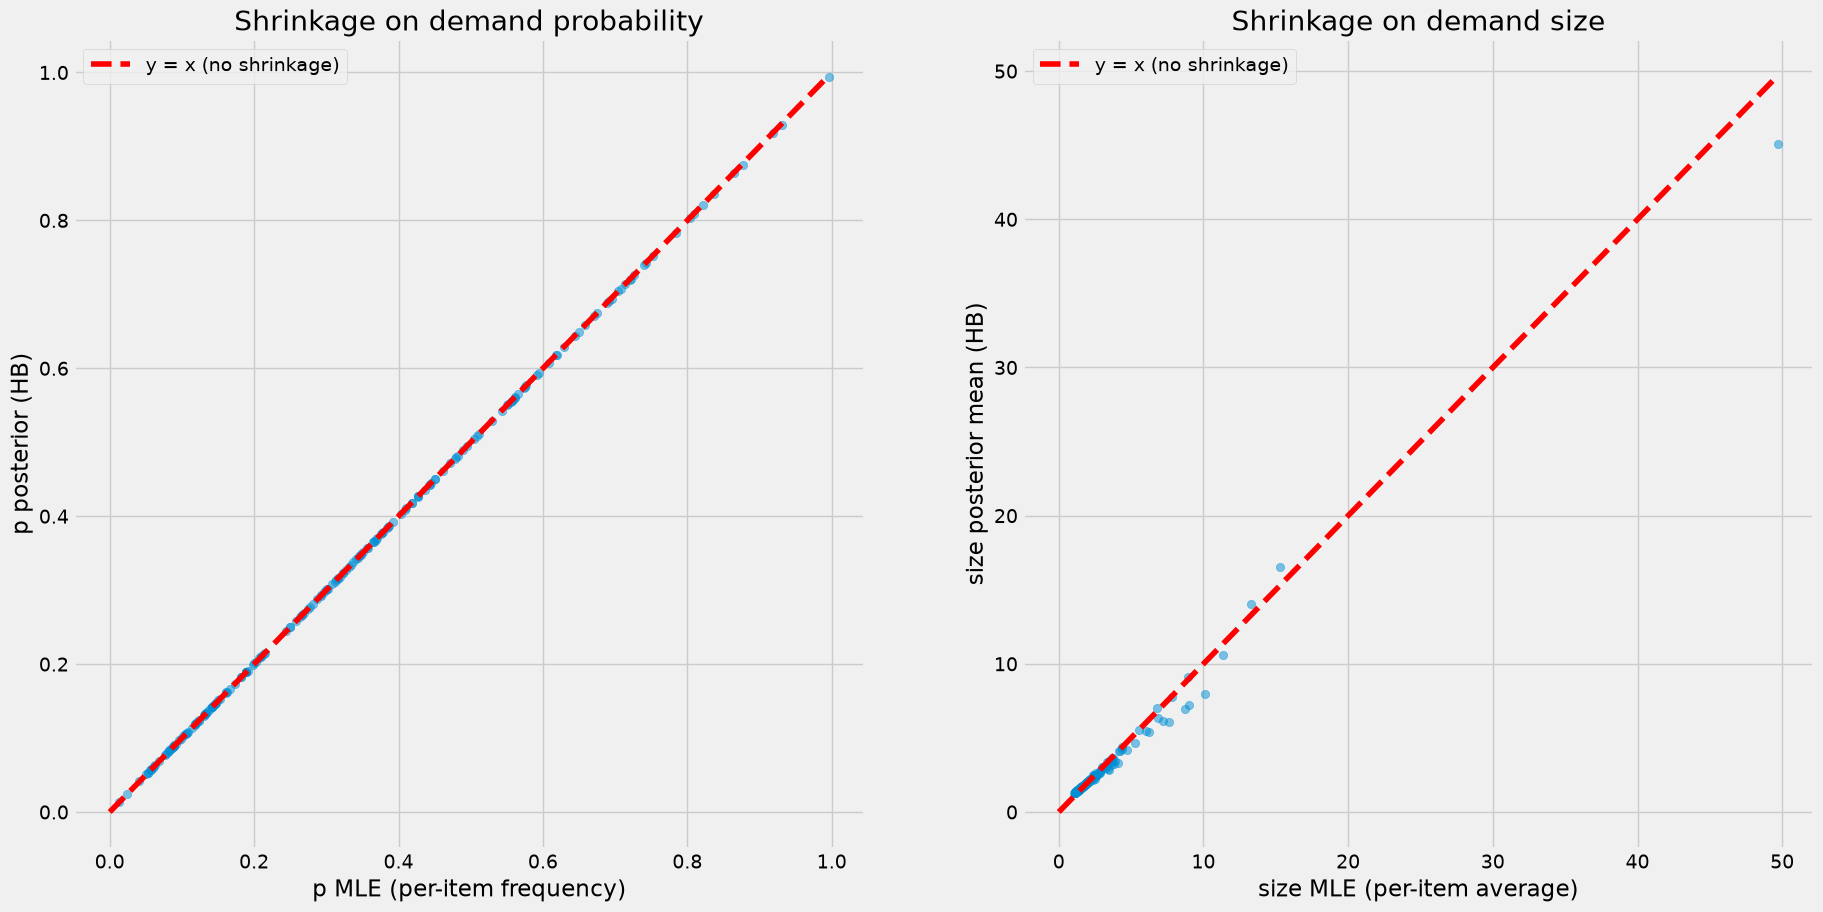

correlation MLE vs posterior — probability: 1.0000, size: 0.9963
variance reduction — probability: 0.37%, size: 16.85%


In [25]:
# raw per-item MLEs, for comparison with the shrunken posteriors
g = panel_train.assign(occ=(panel_train.y > 0).astype(int)).groupby('unique_id')
p_mle = g['occ'].mean()
size_mle = panel_train.loc[panel_train.y > 0].groupby('unique_id')['y'].mean()

fig, axes = plt.subplots(1, 2)

ax = axes[0]
ax.scatter(p_mle, hb_params.p_posterior.reindex(p_mle.index), alpha=0.5)
lim = max(p_mle.max(), 0.05)
ax.plot([0, lim], [0, lim], color='red', linestyle='--', label='y = x (no shrinkage)')
ax.set_xlabel('p MLE (per-item frequency)'); ax.set_ylabel('p posterior (HB)')
ax.set_title('Shrinkage on demand probability'); ax.legend()

ax = axes[1]
size_post = np.exp(hb_params.shrunk_mean_log + hb_params.sigma_sq_process / 2).reindex(size_mle.index)
ax.scatter(size_mle, size_post, alpha=0.5)
lim = size_mle.max()
ax.plot([0, lim], [0, lim], color='red', linestyle='--', label='y = x (no shrinkage)')
ax.set_xlabel('size MLE (per-item average)'); ax.set_ylabel('size posterior mean (HB)')
ax.set_title('Shrinkage on demand size'); ax.legend()
plt.show()

r_p = pearsonr(p_mle, hb_params.p_posterior.reindex(p_mle.index))[0]
r_s = pearsonr(size_mle, size_post)[0]
print(f'correlation MLE vs posterior — probability: {r_p:.4f}, size: {r_s:.4f}')
print(f'variance reduction — probability: {1 - hb_params.p_posterior.reindex(p_mle.index).var()/p_mle.var():.2%}, '
      f'size: {1 - size_post.var()/size_mle.var():.2%}')

This reproduces the paper's Figure 1: what hierarchical shrinkage *does*. Each point is one item, with its raw maximum-likelihood estimate (the per-item frequency, or the per-item average size) on the x-axis and the hierarchical posterior on the y-axis; the red dashed diagonal is the no-shrinkage line.

The two panels should look qualitatively different, and the printed statistics quantify it. For the **occurrence probability** (left), every item contributes all 1800 training days of evidence, so $\lambda_i \approx 1$, the points form along the diagonal, the MLE–posterior correlation is near 1, and the variance reduction is modest (the paper reports r = 0.9987 and −11% variance). 
For the **size** (right), evidence is only the *demand days*: shrinkage kicks in - points bend visibly toward the global mean (extreme x-values pulled down/up toward the center), correlation drops, and the cross-item variance shrinks substantially.

This is the model applying stronger regularization exactly where the data is less reliable - automatically, with no tuning, via the credibility weights.

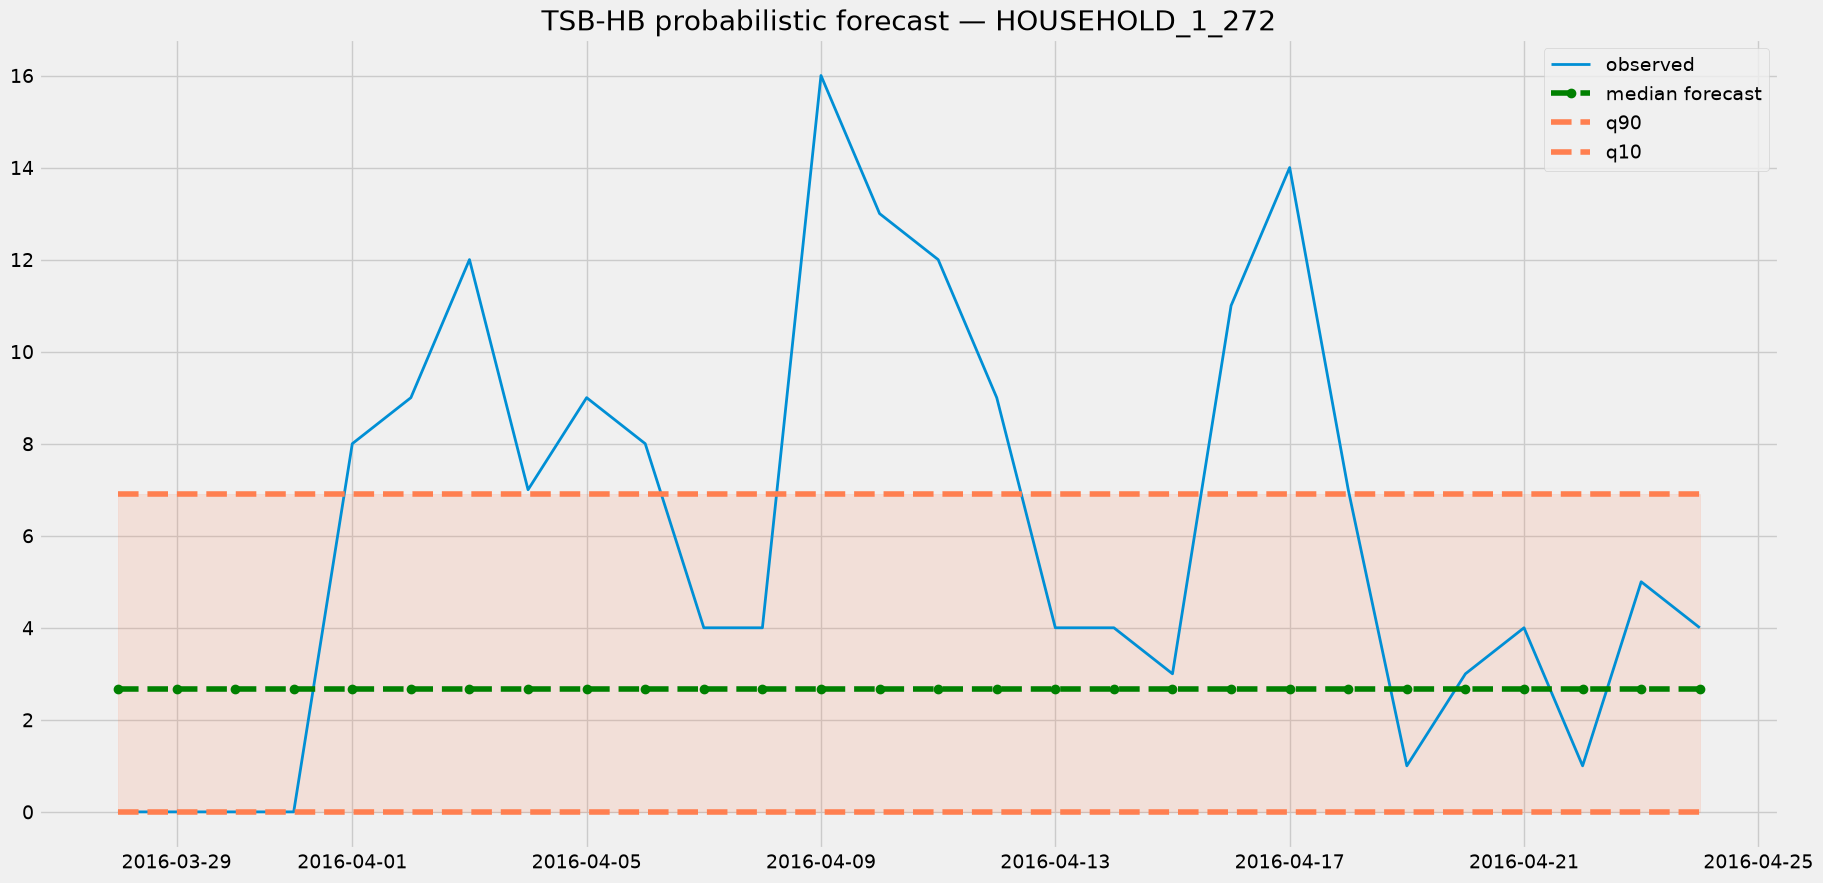

In [26]:
QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]

example_id = results_df.sort_values('delta', ascending=False).unique_id.iloc[0]
g_valid = panel_valid.loc[panel_valid.unique_id == example_id]

q_pred = predict_tsb_hb(hb_params, g_valid[['unique_id', 'ds']], quantiles=QUANTILES)

plt.figure()
plt.plot(g_valid.ds, g_valid.y, linewidth=2, label='observed')
plt.plot(g_valid.ds, q_pred['q_0.5'], color='green', linestyle='--', marker='o', label='median forecast')
plt.plot(g_valid.ds, q_pred['q_0.9'], color='coral', linestyle='--', label='q90')
plt.plot(g_valid.ds, q_pred['q_0.1'], color='coral', linestyle='--', label='q10')
plt.fill_between(g_valid.ds, q_pred['q_0.1'], q_pred['q_0.9'], color='coral', alpha=0.15)
plt.title(f'TSB-HB probabilistic forecast — {example_id}')
plt.legend()
plt.show()

We pick the series where TSB-HB improved most over TSB, request the five standard quantiles, and plot the observed holdout (solid) against the median forecast (green dashed with markers) and the 10–90pct band (coral dashed bounds with a shaded fill).

For a typical intermittent item the *median* sits at exactly **zero**: most of the time most things do not sell. The upper quantile is the operationally useful number: q90 answers "how much stock covers demand on 90pct of days", which is a direct input to a service-level policy. The paper's calibration results show these intervals achieve their nominal coverage with roughly a third of AutoARIMA's interval width.


# Application: forecasting at scale with gradient boosting


In [27]:
def create_features(dt, lags=[28], wins=[7, 28]):
    lag_cols = [f'lag_{lag}' for lag in lags]
    for lag, lag_col in zip(lags, lag_cols):
        dt[lag_col] = dt[['id', 'sales']].groupby('id')['sales'].shift(lag).fillna(-1)

    for win in wins:
        for lag, lag_col in zip(lags, lag_cols):
            dt[f'rmean_{lag}_{win}'] = (dt[['id', lag_col]].groupby('id')[lag_col]
                                        .transform(lambda x: x.rolling(win).mean()).fillna(-1))
    return dt

xdat = create_features(xdat)
xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,sales,date,wday,snap_CA,lag_28,rmean_28_7,rmean_28_28
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0,-1.0,-1.0,-1.0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0,-1.0,-1.0,-1.0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,0,2011-01-29,1,0,-1.0,-1.0,-1.0


We build features for the gb model. Those come in two flavors: 

- **Lag features**: `groupby('id')['sales'].shift(lag)` puts the demand from `lag` days ago on today's row. The `groupby` ensures the shift stays within each series. We use lag 28 (= the forecast horizon) so that the feature is available for *every* day we will predict, with no recursive feeding of predictions into features.
- **Rolling means over lags**: `transform(lambda x: x.rolling(win).mean())` smooths the lagged series over 7 and 28-day windows, giving the model a recent-demand-level signal. This is analogous the same job Croston's smoothed level $a_t$ performs, but learned jointly with everything else.

Missing values (the first `lag + win` days of each series, where the window isn't filled yet) are set to `-1`: tree-based models handle such sentinel values by simply learning a split around them.

In [28]:
# time-based features
xdat['week'] = xdat['date'].dt.isocalendar().week.astype('int16')

date_features = {
    'wday': 'weekday',
    'month': 'month',
    'quarter': 'quarter',
    'year': 'year',
    'mday': 'day',
}

for date_feat_name, date_feat_func in date_features.items():
    if date_feat_name in xdat.columns:
        xdat[date_feat_name] = xdat[date_feat_name].astype('int16')
    else:
        xdat[date_feat_name] = getattr(xdat['date'].dt, date_feat_func).astype('int16')

# encode categorical features
cat_feats = ['item_id', 'dept_id', 'store_id', 'cat_id']
for cc in cat_feats:
    le = LabelEncoder()
    xdat[cc] = le.fit_transform(xdat[cc])

xdat.head(3)

,id,item_id,dept_id,cat_id,store_id,sales,date,wday,snap_CA,lag_28,rmean_28_7,rmean_28_28,week,month,quarter,year,mday
0,HOBBIES_1_001_CA_1_validation,1437,3,1,0,0,2011-01-29,1,0,-1.0,-1.0,-1.0,4,1,1,2011,29
1,HOBBIES_1_002_CA_1_validation,1438,3,1,0,0,2011-01-29,1,0,-1.0,-1.0,-1.0,4,1,1,2011,29
2,HOBBIES_1_003_CA_1_validation,1439,3,1,0,0,2011-01-29,1,0,-1.0,-1.0,-1.0,4,1,1,2011,29


Two more feature blocks:
-  The **calendar features** are extracted from the datetime index via the `.dt` accessor. Weekday, week-of-year, month, quarter, year and day-of-month let the model learn weekly cycles and seasonal patterns directly. Casting to `int16` instead of the default `int64` quarters the memory footprint, which matters on a frame with millions of rows - even in 2026.

- The **categorical identifiers** (`item_id`, `dept_id`, `store_id`, `cat_id`) are integer-encoded with scikit-learn's `LabelEncoder` (each distinct string gets an integer). LightGBM can split on these directly; through them, the single global model can still learn item-specific and store-specific behavior; this is a regression analogue of the per-item parameters in the earlier models.

In [29]:
# split into train and test — chronological, same 28-day horizon as before
cutoff = xdat.date.max() - pd.to_timedelta(CFG.horizon, unit='D')
xtrain = xdat.loc[xdat.date < cutoff].copy()
xvalid = xdat.loc[xdat.date >= cutoff].copy()
del xdat

ytrain = xtrain['sales'].copy()
yvalid = xvalid['sales'].copy()

drop_cols = ['id', 'wday', 'sales', 'snap_CA', 'year', 'date']
xtrain.drop(drop_cols, axis=1, inplace=True)
xvalid.drop(drop_cols, axis=1, inplace=True)

dtrain = lgb.Dataset(xtrain, label=ytrain, free_raw_data=False)
dvalid = lgb.Dataset(xvalid, label=yvalid, free_raw_data=False)

xtrain.head(3)

,item_id,dept_id,cat_id,store_id,lag_28,rmean_28_7,rmean_28_28,week,month,quarter,mday
0,1437,3,1,0,-1.0,-1.0,-1.0,4,1,1,29
1,1438,3,1,0,-1.0,-1.0,-1.0,4,1,1,29
2,1439,3,1,0,-1.0,-1.0,-1.0,4,1,1,29


The split is  **chronological** (NEVER EVER DO ANYTHING ELSE WITH TIME SERIES), using the same 28-day cutoff logic before. The target `sales` is separated out, identifier and leakage-prone columns are dropped (the raw `date` itself, the redundant `wday` duplicate, `year` which would let the model memorize the level of specific years rather than generalize), and `del xdat` releases the full frame from memory before LightGBM copies the data.

`lgb.Dataset` wraps features and labels into LightGBM's internal binned format; `free_raw_data=False` keeps the underlying pandas data alive so the dataset can be reused across the two training runs below.

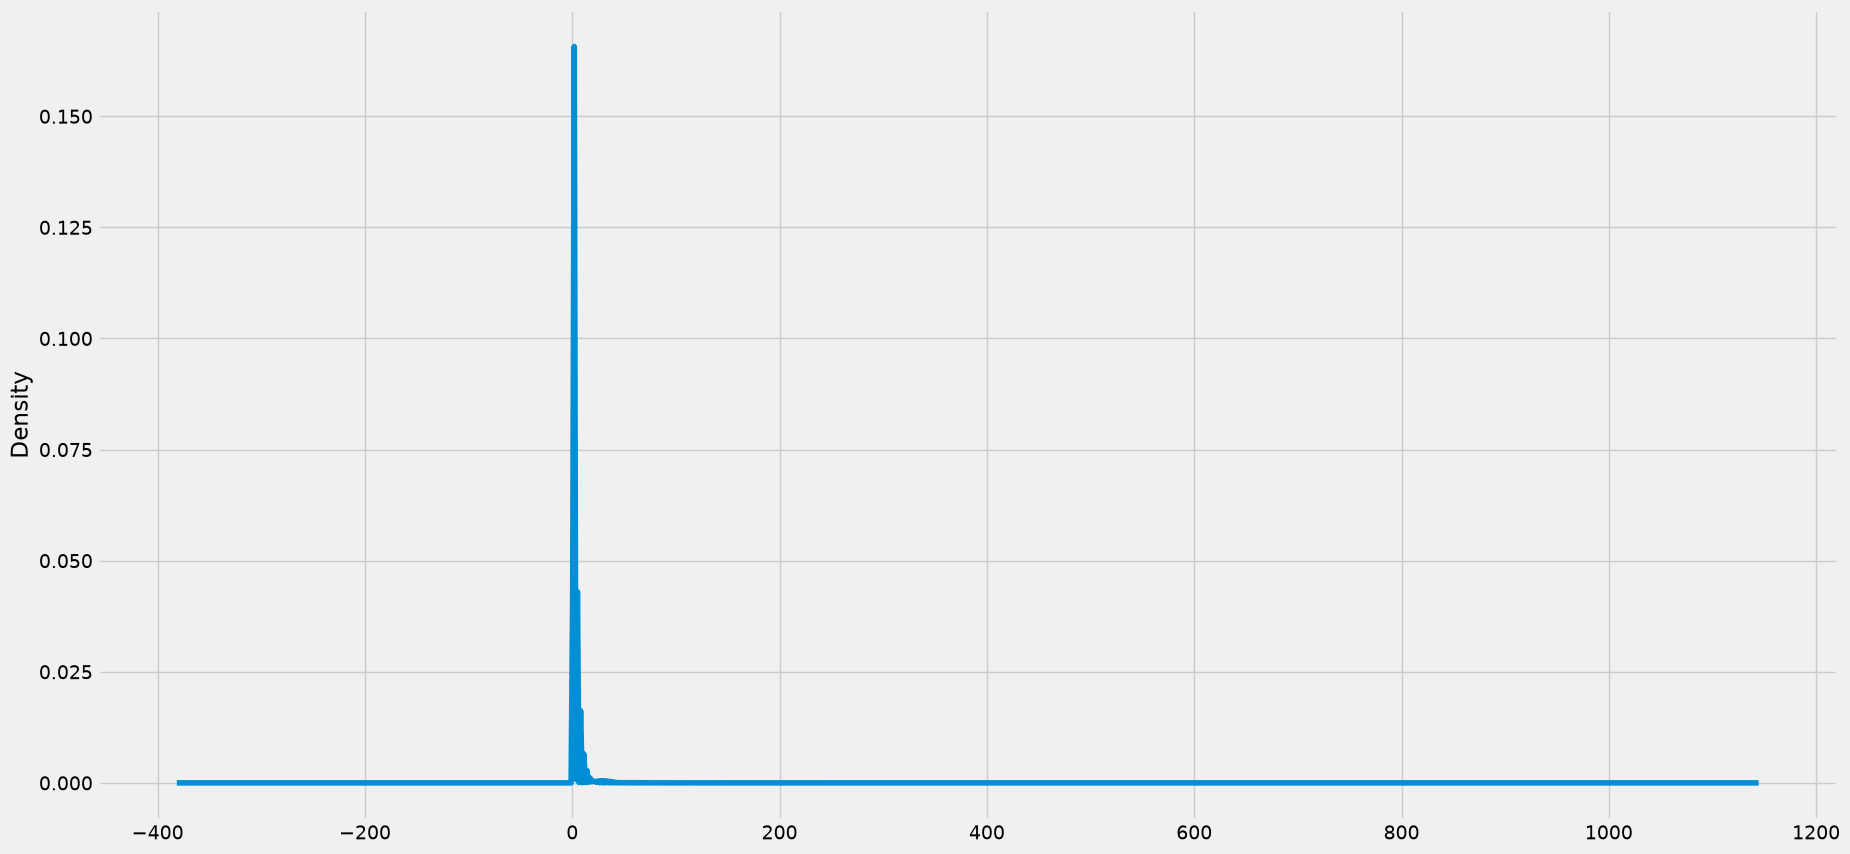

In [30]:
ytrain.plot.density()
print()

In [31]:
LGB_PARAMS = {
    'metric': 'rmse',
    'learning_rate': 0.075,
    'sub_feature': 0.8,
    'sub_row': 0.75,
    'bagging_freq': 1,
    'lambda_l2': 0.1,
    'verbosity': 1,
    'num_iterations': 1000,
    'num_leaves': 128,
    'min_data_in_leaf': 50,
}

m_poisson = lgb.train(dict(LGB_PARAMS, objective='poisson'),
                      dtrain, valid_sets=[dtrain, dvalid],
                      callbacks=[lgb.early_stopping(150), lgb.log_evaluation(100)])

forecast_metrics(yvalid, m_poisson.predict(xvalid))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.073179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 965
[LightGBM] [Info] Number of data points in the train set: 22977264, number of used features: 11
[LightGBM] [Info] Start training from score 0.203045
Training until validation scores don't improve for 150 rounds
[100]	training's rmse: 2.66383	valid_1's rmse: 2.33185
[200]	training's rmse: 2.61925	valid_1's rmse: 2.3214
[300]	training's rmse: 2.57912	valid_1's rmse: 2.31679
[400]	training's rmse: 2.55221	valid_1's rmse: 2.31651
[500]	training's rmse: 2.53173	valid_1's rmse: 2.31832
Early stopping, best iteration is:
[363]	training's rmse: 2.56246	valid_1's rmse: 2.31553


{'me': 0.006, 'mae': 1.1429, 'rmse': 2.3155}

The first global model uses the **Poisson objective**: LightGBM maximizes a Poisson likelihood, fitting the trees on the log of the expected count and predicting nonnegative rates — a natural first choice for "units sold per day". The shared `LGB_PARAMS` dictionary holds the gradient-boosting hyperparameters: a moderate learning rate (0.075) with up to 1,000 boosting rounds, feature and row subsampling (`sub_feature`, `sub_row`, refreshed every iteration via `bagging_freq=1`) for regularization-by-randomness, an L2 penalty on leaf values, fairly deep trees (`num_leaves=128`) restrained by requiring at least 50 samples per leaf.

Two callbacks manage the run: `early_stopping(150)` halts training when the validation RMSE has not improved for 150 rounds and rolls back to the best iteration (=  "defense" against overfitting) and `log_evaluation(100)` prints the train/valid metric every 100 rounds, letting us watch the two curves and spot divergence. 

The final metrics line scores the model on the holdout with our standard helper, on the same 28 days the Croston family was evaluated on.

In [32]:
m_tweedie = lgb.train(dict(LGB_PARAMS, objective='tweedie'),
                      dtrain, valid_sets=[dtrain, dvalid],
                      callbacks=[lgb.early_stopping(150), lgb.log_evaluation(100)])

forecast_metrics(yvalid, m_tweedie.predict(xvalid))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075312 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 965
[LightGBM] [Info] Number of data points in the train set: 22977264, number of used features: 11
[LightGBM] [Info] Start training from score 0.203045
Training until validation scores don't improve for 150 rounds
[100]	training's rmse: 2.67983	valid_1's rmse: 2.30314
[200]	training's rmse: 2.6414	valid_1's rmse: 2.29437
[300]	training's rmse: 2.61341	valid_1's rmse: 2.29108
[400]	training's rmse: 2.5914	valid_1's rmse: 2.29104
Early stopping, best iteration is:
[289]	training's rmse: 2.61873	valid_1's rmse: 2.29018


{'me': -0.01, 'mae': 1.139, 'rmse': 2.2902}

We change the objective to 'tweedie': the [Tweedie distribution](https://en.wikipedia.org/wiki/Tweedie_distribution) family interpolates between Poisson and Gamma; for power parameter $1 < p < 2$ (LightGBM defaults to 1.5) it is a **compound Poisson–Gamma**: a Poisson number of events, each with a Gamma-distributed size = almost verbatim, the occurrence x size decomposition the entire Croston family is built on, now expressed as a loss function. 

The practical consequence is a distribution with an exact point mass at zero plus a skewed continuous part, matching the density plot above better than pure Poisson (which puts mass at 0 but ties the variance to the mean). 

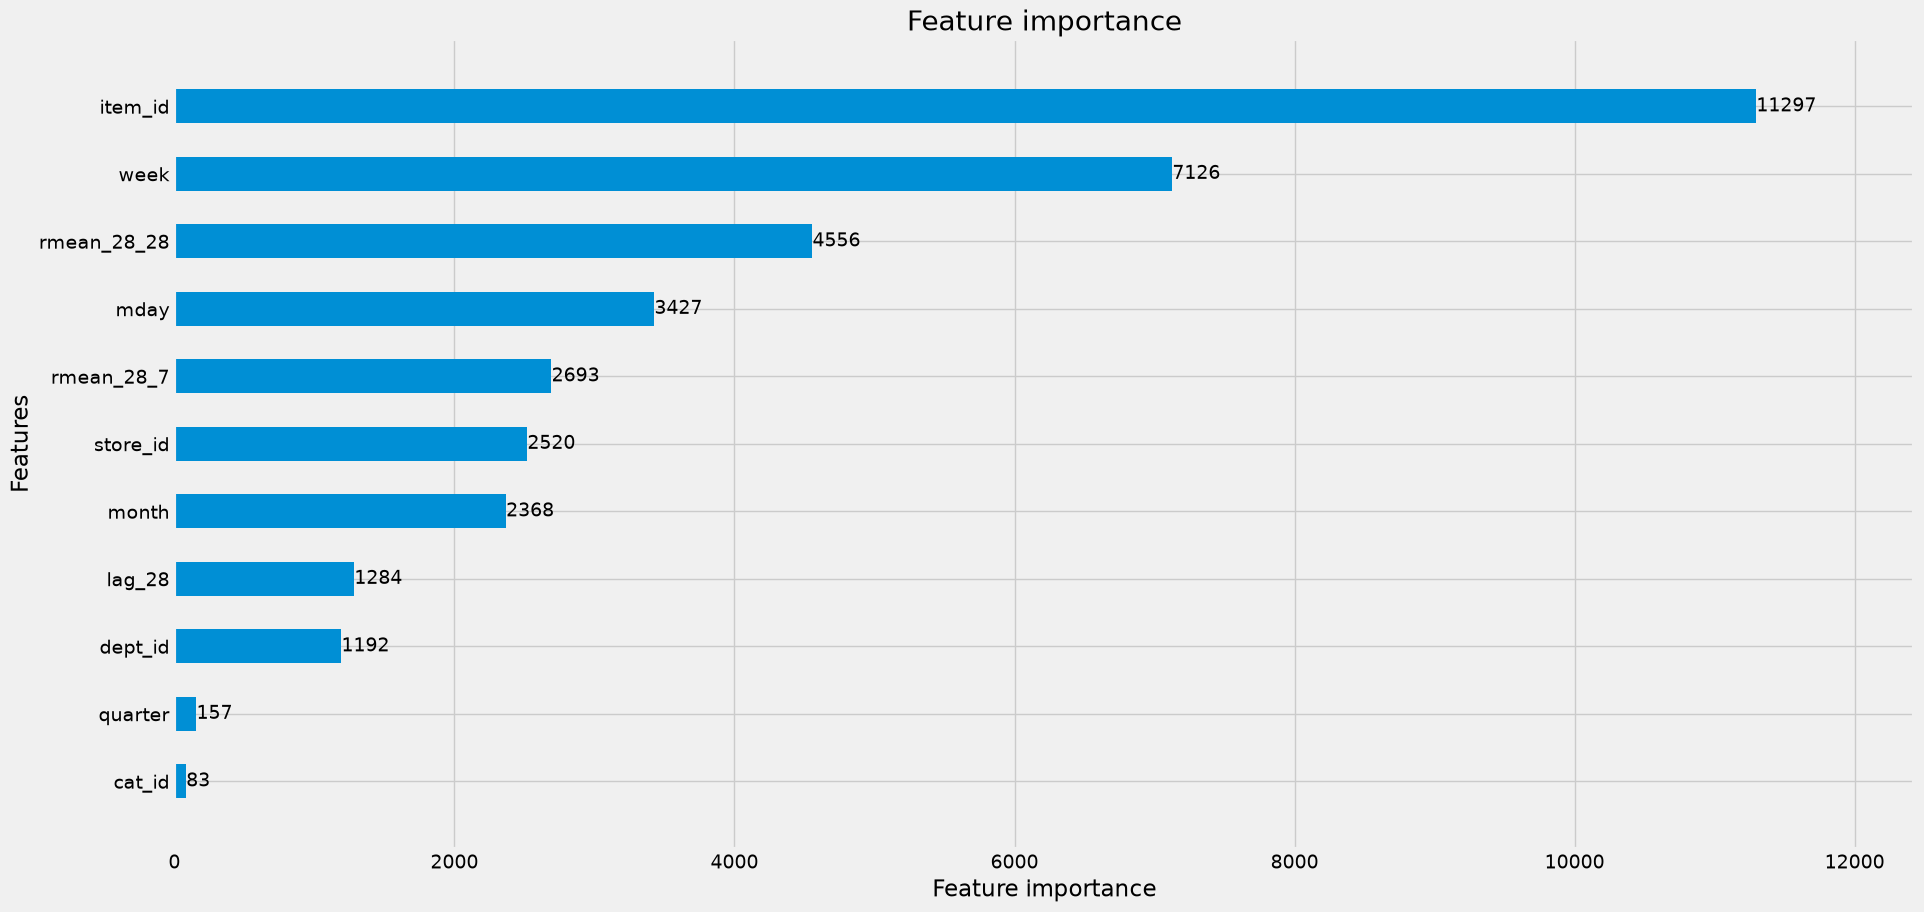

In [33]:
lgb.plot_importance(m_tweedie, height=0.5)
print()

`plot_importance` ranks features by how often they were used in splits. The **rolling means of lagged sales dominate** - recent demand level is the strongest predictor,  followed by the item identifier (per-item base rates) and calendar features (the weekly cycle). This plot is a debugging tool: a feature you *expected* to matter sitting at zero importance usually indicates a bug in its construction, and an implausibly dominant feature is the classic symptom of target leakage.